# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [85]:
import pandas as pd
from pandas import DataFrame

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [8]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [11]:
# Sua resposta aqui
df.shape

#retorna o número de linhas X colunas em uma tupla

(300, 9)

## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [18]:
# Sua resposta aqui
df.isnull().sum()

,0
Data_Venda,0
Canal_Venda,7
UF,6
Produto,0
Preco_Unitario,5
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [36]:
# Sua resposta aqui

print(f"Receita total: R${df["Receita"].sum()}")

print(f"Lucro total: R${df["Lucro"].sum()}")

print(f"Ticket médio: R${(df['Receita'].sum() / df['Quantidade'].sum()):.2f}")

print(f"Quantidade total vendida: {df['Quantidade'].sum()}")

print(f"[Bônus] relação entre receita e lucro: {df["Lucro"].corr(df["Receita"]):.2f}")

Receita total: R$707535.36
Lucro total: R$189625.88
Ticket médio: R$1409.43
Quantidade total vendida: 502
[Bônus] relação entre receita e lucro: 0.97


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [58]:
# Sua resposta aqui

# item 1
df.groupby("Canal_Venda")["Receita"].agg("sum").sort_values(ascending=False)
#Resposta: E-commerce

# item 2
df.groupby("Produto")["Lucro"].agg("sum").sort_values(ascending=False)
#Resposta: Notebook

# item 3
df.groupby("UF")["Receita"].agg("sum").sort_values(ascending=False).head(3)

,Receita
UF,
SP,133727.80
MG,103438.61
RJ,100284.68


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

<Axes: xlabel='Canal_Venda', ylabel='Density'>

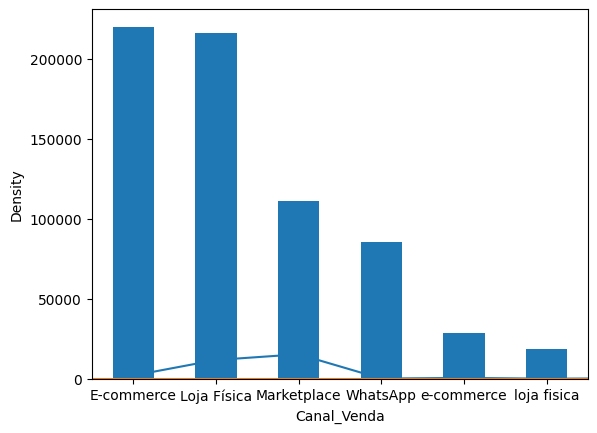

In [90]:
# Sua resposta aqui

# a) R: gráfico de linha
df.groupby("Data_Venda")["Receita"].sum().sort_index().plot(rot=90)

# b) R: gráfico de barra
df.groupby("Canal_Venda")["Receita"].sum().plot(kind="bar")

# c) R: gráfico de densidade
df["Custo_Unitario"].plot(kind="density")

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [ ]:
# Sua resposta aqui

## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**